In [10]:
import json
import numpy as np
import pymultinest
import matplotlib.pyplot as plt
import os
os.makedirs("recta", exist_ok=True)

In [2]:
data1 =np.loadtxt("line-1.dat")

In [3]:
x = data1[0]
y = data1[1]

In [4]:
def recta(theta, x):
    return x*theta[0] + theta[1]

In [5]:
def prior(cube, ndim, nparams):

    cube[0] = -10 + 20*cube[0]
    cube[1] = -10 + 20*cube[1]

In [6]:
def loglike(cube, ndim, nparams):

    y_model = recta(cube, x)

    chi2 = np.sum((y - y_model)**2)

    return -0.5*chi2

In [8]:
parameters = ["m", "b"]

pymultinest.run(
    loglike,
    prior,
    2,
    outputfiles_basename='recta/',
    resume=False,
    verbose=False
)

json.dump(parameters, open('recta/params.json', 'w'))

 *****************************************************
 MultiNest v3.10
 Copyright Farhan Feroz & Mike Hobson
 Release Jul 2015

 no. of live points =  400
 dimensionality =    2
 *****************************************************
 ln(ev)=  -8.7985404185989662      +/-  0.14001189756818302     
 Total Likelihood Evaluations:         5798
 Sampling finished. Exiting MultiNest


"ln(ev)" es la __evidencia bayesiana__ que sirve para comparar modelos. Entre menor sea, mejor es el modelo.

  analysing data from recta/.txt


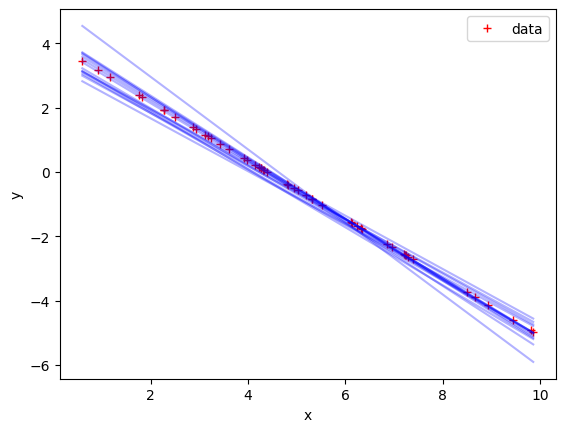

In [9]:
plt.figure()

plt.plot(x, y, '+', color='red', label='data')

a = pymultinest.Analyzer(
    n_params=2,
    outputfiles_basename='recta/'
)

for sample in a.get_equal_weighted_posterior()[::100]:

    m = sample[0]
    b = sample[1]

    plt.plot(
        x,
        m*x + b,
        '-',
        color='blue',
        alpha=0.3
    )

plt.xlabel('x')
plt.ylabel('y')

plt.legend()

plt.savefig('recta/posterior.pdf')

plt.show()
